# Tugas 3: Generasi Judul Berita dengan Encoder-Decoder dan Transformer
- Penulis: Ach. Nur Aqil Wahid
- Deskripsi singkat: Membangun tiga arsitektur model generatif untuk membuat judul dari artikel berita.

# Import Library

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer

# Load & Persiapan Dataset

In [2]:
# Tambahkan path project root ke Python path
project_root = os.path.abspath('..')  # karena notebook ada di dalam notebooks/
sys.path.append(project_root)

print("✔️ Path ditambahkan:", project_root)

✔️ Path ditambahkan: c:\Users\aqilw\UGM\2. Semester 2\Pemrosesan Bahasa Alami Lanjut (PBAL)\3. Tugas Generasi Judul Berita\Generasi-Judul-Berita


In [3]:
file_path = r"C:\Users\aqilw\UGM\2. Semester 2\Pemrosesan Bahasa Alami Lanjut (PBAL)\3. Tugas Generasi Judul Berita\Generasi-Judul-Berita\data\newsapi_articles.json"

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

raw_inputs = [item['content'] for item in data if item['content'] and item['title']]
raw_targets = [item['title'] for item in data if item['content'] and item['title']]

print(f"Jumlah data: {len(raw_inputs)}")
print(f"Contoh judul: {raw_targets[0]}")

Jumlah data: 94
Contoh judul: All of the updates about OpenAI


In [4]:
from utils.preprocessing import (
    clean_text,
    prepare_tokenizer,
    encode_sequences,
    get_train_test_split
)

# Bersihkan teks
inputs = [clean_text(text) for text in raw_inputs]
targets = [f"<start> {clean_text(text)} <end>" for text in raw_targets]

# Tokenisasi
input_tokenizer, target_tokenizer = prepare_tokenizer(inputs, targets)

# Sequence dan padding
input_seq, target_seq = encode_sequences(
    input_tokenizer, target_tokenizer,
    inputs, targets,
    max_len_input=300,
    max_len_target=30
)

# Split
X_train, X_test, y_train, y_test = get_train_test_split(input_seq, target_seq)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 75 | Test size: 19


# Model 1: Encoder-Decoder LSTM

In [5]:
from models.encoder_decoder_lstm import build_lstm_seq2seq_model

# Dapatkan ukuran vocab
input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

model = build_lstm_seq2seq_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=30
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 30)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 300, 128)     178048      ['input_1[0][0]']                
                                                                                                  
 embedding_1 (Embedding)        (None, 30, 128)      80896       ['input_2[0][0]']                
                                                                                              

### Decoder Inputs & Outputs

In [6]:
import numpy as np

def create_decoder_data(target_seq):
    decoder_input_data = target_seq[:, :-1]  # semua kecuali token terakhir
    decoder_target_data = target_seq[:, 1:]  # semua kecuali token pertama
    return decoder_input_data, decoder_target_data

decoder_input_train, decoder_target_train = create_decoder_data(y_train)
decoder_input_test, decoder_target_test = create_decoder_data(y_test)

### Build & Compile Model

In [7]:
from models.encoder_decoder_lstm import build_lstm_seq2seq_model

input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

model = build_lstm_seq2seq_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=29  # karena kita geser 1
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 300, 128)     178048      ['input_3[0][0]']                
                                                                                                  
 embedding_3 (Embedding)        (None, 29, 128)      80896       ['input_4[0][0]']                
                                                                                            

### Latih Model

In [8]:
history = model.fit(
    [X_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),  # karena pakai sparse_categorical_crossentropy
    validation_split=0.1,
    batch_size=16,
    epochs=20
)


Epoch 1/20
5/5 [==============================] - 6s 239ms/step - loss: 6.3924 - accuracy: 0.4102 - val_loss: 6.1310 - val_accuracy: 0.5388
Epoch 2/20
5/5 [==============================] - 0s 46ms/step - loss: 4.9104 - accuracy: 0.5569 - val_loss: 3.2898 - val_accuracy: 0.5388
Epoch 3/20
5/5 [==============================] - 0s 49ms/step - loss: 3.0577 - accuracy: 0.5569 - val_loss: 3.0359 - val_accuracy: 0.5431
Epoch 4/20
5/5 [==============================] - 0s 45ms/step - loss: 2.7975 - accuracy: 0.5677 - val_loss: 2.9892 - val_accuracy: 0.5647
Epoch 5/20
5/5 [==============================] - 0s 45ms/step - loss: 2.7085 - accuracy: 0.5682 - val_loss: 3.0205 - val_accuracy: 0.5647
Epoch 6/20
5/5 [==============================] - 0s 45ms/step - loss: 2.6507 - accuracy: 0.5656 - val_loss: 3.0414 - val_accuracy: 0.5690
Epoch 7/20
5/5 [==============================] - 0s 45ms/step - loss: 2.6260 - accuracy: 0.5651 - val_loss: 3.0822 - val_accuracy: 0.5647
Epoch 8/20
5/5 [==========

### Visualisasi Training Loss & Akurasi

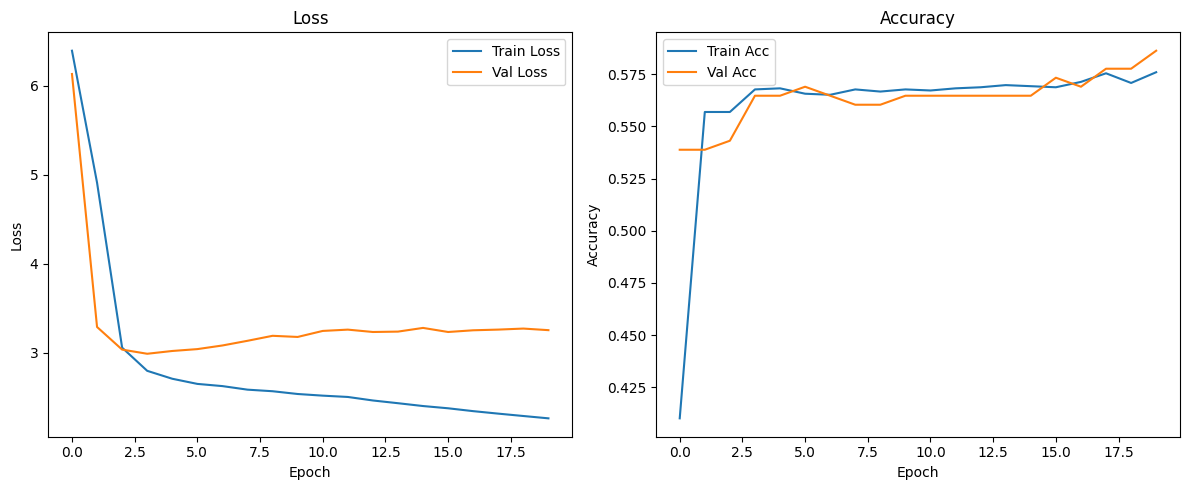

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Panggil fungsi
plot_training_history(history)


### Fungsi Inference (Generate Judul)

In [10]:
def decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29):
    reverse_target_word_index = {i: w for w, i in target_tokenizer.word_index.items()}
    decoder_input = np.zeros((1, decoder_max_len))

    output_seq = model.predict([input_seq_single, decoder_input])
    output_tokens = np.argmax(output_seq[0], axis=-1)

    decoded_sentence = []
    for idx in output_tokens:
        word = reverse_target_word_index.get(idx, '')
        if word in ('<end>', ''):
            break
        if word != '<start>':
            decoded_sentence.append(word)
    
    return ' '.join(decoded_sentence)

### Generate Judul & Simpan ke CSV

In [11]:
# Ambil sampel dari test set
num_samples = len(X_test)
generated = []

for i in range(num_samples):    
    input_seq_single = np.expand_dims(X_test[i], axis=0)
    generated_title = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer)
    original_article = raw_inputs[i]
    actual_title = raw_targets[i]
    
    generated.append({
        'original_article': original_article,
        'actual_title': actual_title,
        'generated_title': generated_title
    })

# Simpan ke CSV
df_generated = pd.DataFrame(generated)
df_generated.to_csv('../outputs/generated_headlines.csv', index=False)

print("✅ Headline berhasil disimpan ke outputs/generated_headlines.csv")


1/1 [==============================] - 0s 36ms/step
✅ Headline berhasil disimpan ke outputs/generated_headlines.csv


-------------------

# Model 2: Encoder-Decoder + Attention

In [12]:
from models.encoder_decoder_attention import build_lstm_attention_model

model_attn = build_lstm_attention_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=29
)

model_attn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_attn.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 300, 128)     178048      ['input_5[0][0]']                
                                                                                                  
 embedding_5 (Embedding)        (None, 29, 128)      80896       ['input_6[0][0]']                
                                                                                            

### Train Model 2

In [13]:
history_attn = model_attn.fit(
    [X_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),
    validation_split=0.1,
    batch_size=16,
    epochs=20
)


Epoch 1/20
5/5 [==============================] - 4s 249ms/step - loss: 6.3238 - accuracy: 0.4297 - val_loss: 5.5480 - val_accuracy: 0.5388
Epoch 2/20
5/5 [==============================] - 0s 46ms/step - loss: 3.9719 - accuracy: 0.5569 - val_loss: 3.2149 - val_accuracy: 0.5388
Epoch 3/20
5/5 [==============================] - 0s 51ms/step - loss: 2.8379 - accuracy: 0.5569 - val_loss: 3.0125 - val_accuracy: 0.5388
Epoch 4/20
5/5 [==============================] - 0s 63ms/step - loss: 2.7166 - accuracy: 0.5564 - val_loss: 3.1643 - val_accuracy: 0.5603
Epoch 5/20
5/5 [==============================] - 0s 56ms/step - loss: 2.6661 - accuracy: 0.5646 - val_loss: 3.1894 - val_accuracy: 0.5647
Epoch 6/20
5/5 [==============================] - 0s 47ms/step - loss: 2.6040 - accuracy: 0.5687 - val_loss: 3.2426 - val_accuracy: 0.5647
Epoch 7/20
5/5 [==============================] - 0s 45ms/step - loss: 2.5800 - accuracy: 0.5682 - val_loss: 3.2762 - val_accuracy: 0.5647
Epoch 8/20
5/5 [==========

### Evaluate + Generate Headline

In [14]:
generated_title = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)

1/1 [==============================] - 1s 689ms/step


In [15]:
df_generated.to_csv('../outputs/generated_headlines_attention.csv', index=False)

### Visualisasi Loss dan Akurasi Model 2

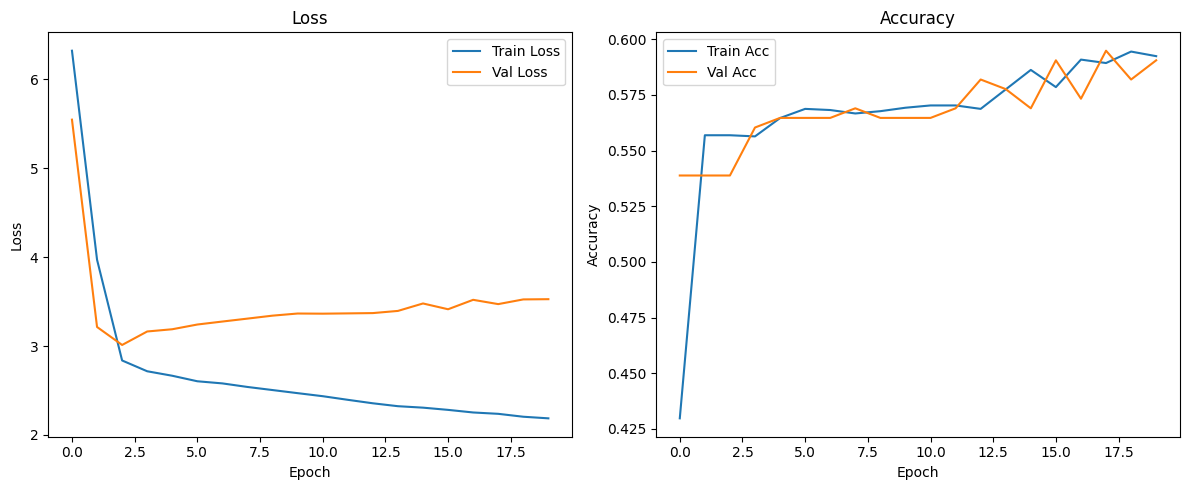

In [16]:
plot_training_history(history_attn)


### Perebandingan dua model dalam satu grafik

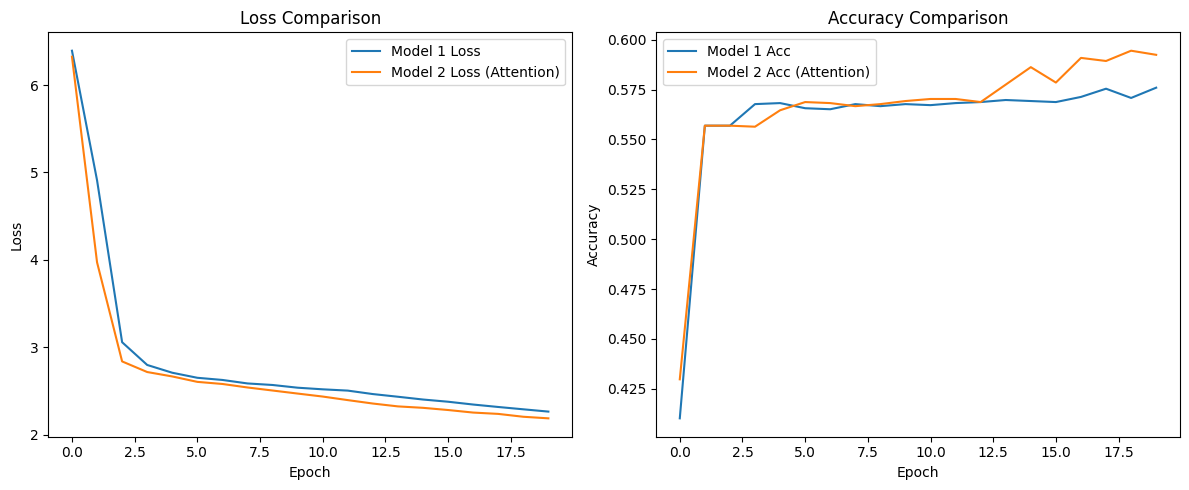

In [17]:
plt.figure(figsize=(12, 5))

# Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Model 1 Loss')
plt.plot(history_attn.history['loss'], label='Model 2 Loss (Attention)')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Model 1 Acc')
plt.plot(history_attn.history['accuracy'], label='Model 2 Acc (Attention)')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Evaluasi Kualitatif: Bandingkan Headline

In [18]:
from IPython.display import display, Markdown

for i in range(5):  # ambil 5 sampel untuk analisis
    input_seq_single = np.expand_dims(X_test[i], axis=0)

    gen_title_1 = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    gen_title_2 = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)

    display(Markdown(f"""
**Artikel**:
{raw_inputs[i]}

**Judul Asli**:
🟢 {raw_targets[i]}

**Model 1 (tanpa Attention)**:
🔵 {gen_title_1}

**Model 2 (dengan Attention)**:
🟣 {gen_title_2}
---
"""))


1/1 [==============================] - 0s 46ms/step



**Artikel**:
What was once a humble research lab has transformed into one of the biggest consumer technology companies of all time.
OpenAI, founded in 2015 to develop artificial general intelligence (AGI) AI sys… [+18212 chars]

**Judul Asli**:
🟢 All of the updates about OpenAI

**Model 1 (tanpa Attention)**:
🔵 ai ai ai ai ai

**Model 2 (dengan Attention)**:
🟣 the ai ai ai ai
---


1/1 [==============================] - 0s 36ms/step



**Artikel**:
Stanfords report shows Chinese AI is on the rise overall, with models from Chinese companies scoring similar to their US counterparts on the LMSYS benchmark. It notes that China publishes more AI pap… [+3227 chars]

**Judul Asli**:
🟢 The AI Race Has Gotten Crowded—and China Is Closing In on the US

**Model 1 (tanpa Attention)**:
🔵 ai ai ai ai ai

**Model 2 (dengan Attention)**:
🟣 the ai ai ai ai
---


1/1 [==============================] - 0s 38ms/step



**Artikel**:
According to a panel of hundreds of artificial intelligence researchers, the field is currently pursuing artificial general intelligence the wrong way.
This insight was revealed at the Association f… [+4217 chars]

**Judul Asli**:
🟢 AI Experts Say We’re on the Wrong Path to Achieving Human-Like AI

**Model 1 (tanpa Attention)**:
🔵 ai ai ai ai ai

**Model 2 (dengan Attention)**:
🟣 the ai ai ai ai
---


1/1 [==============================] - 0s 39ms/step



**Artikel**:
All of the 400 exposed AI systems found by UpGuard have one thing in common: They use the open source AI framework called llama.cpp. This software allows people to relatively easily deploy open sourc… [+3300 chars]

**Judul Asli**:
🟢 Sex-Fantasy Chatbots Are Leaking a Constant Stream of Explicit Messages

**Model 1 (tanpa Attention)**:
🔵 ai ai ai ai ai

**Model 2 (dengan Attention)**:
🟣 the ai ai ai ai
---


1/1 [==============================] - 0s 39ms/step



**Artikel**:
Artists are combining traditional methods with AI image generation.
Artists are combining traditional methods with AI image generation.
The arguments against AI in art are obvious. Most visual arti… [+7856 chars]

**Judul Asli**:
🟢 Is there a ‘right’ way to use AI in art?

**Model 1 (tanpa Attention)**:
🔵 ai ai ai ai ai

**Model 2 (dengan Attention)**:
🟣 the ai ai ai ai
---


-----------------

# Model 3: Transformer

Menggunakan Custom Transformers karena pytorch saya bentrok dengan Tensorflow

### Positional Encoding Layer

In [19]:
import tensorflow as tf

class PositionalEncoding(tf.keras.layers.Layer):
    def call(self, inputs):
        positions = tf.range(tf.shape(inputs)[1])[:, tf.newaxis]
        return inputs + tf.cast(positions, tf.float32)

### Transformer Block Function

In [20]:
def transformer_block(embed_dim, num_heads, ff_dim):
    inputs = tf.keras.Input(shape=(None, embed_dim))
    attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attention = tf.keras.layers.Add()([inputs, attention])
    attention = tf.keras.layers.LayerNormalization()(attention)

    ff = tf.keras.layers.Dense(ff_dim, activation="relu")(attention)
    ff = tf.keras.layers.Dense(embed_dim)(ff)
    outputs = tf.keras.layers.Add()([attention, ff])
    outputs = tf.keras.layers.LayerNormalization()(outputs)
    return tf.keras.Model(inputs=inputs, outputs=outputs)


### Model Custom Transformer

In [29]:
embed_dim = 128
num_heads = 4
ff_dim = 512

input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

# Encoder
encoder_inputs = tf.keras.Input(shape=(300,))
x = tf.keras.layers.Embedding(input_vocab_size, embed_dim)(encoder_inputs)
x = PositionalEncoding()(x)
x = transformer_block(embed_dim, num_heads, ff_dim)(x)

# Decoder
decoder_inputs = tf.keras.Input(shape=(29,))
y = tf.keras.layers.Embedding(target_vocab_size, embed_dim)(decoder_inputs)
y = PositionalEncoding()(y)
y = transformer_block(embed_dim, num_heads, ff_dim)(y)

# Decoder memperhatikan Encoder
context = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)(y, x)
concat = tf.keras.layers.Concatenate()([y, context])

outputs = tf.keras.layers.Dense(target_vocab_size, activation='relu')(concat)

model_tf = tf.keras.Model([encoder_inputs, decoder_inputs], outputs)
model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tf.summary()


Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_17 (InputLayer)          [(None, 29)]         0           []                               
                                                                                                  
 input_15 (InputLayer)          [(None, 300)]        0           []                               
                                                                                                  
 embedding_11 (Embedding)       (None, 29, 128)      80896       ['input_17[0][0]']               
                                                                                                  
 embedding_10 (Embedding)       (None, 300, 128)     178048      ['input_15[0][0]']               
                                                                                           

### Training Model

In [ ]:
history_tf = model_tf.fit(
    [X_train, decoder_input_train],
    tf.expand_dims(decoder_target_train, -1),
    validation_split=0.1,
    batch_size=16,
    epochs=15
)

Epoch 1/15
5/5 [==============================] - 3s 168ms/step - loss: 4.3370 - accuracy: 0.4251 - val_loss: 3.7060 - val_accuracy: 0.5388
Epoch 2/15
5/5 [==============================] - 0s 37ms/step - loss: 3.4303 - accuracy: 0.5569 - val_loss: 3.4649 - val_accuracy: 0.5388
Epoch 3/15
5/5 [==============================] - 0s 39ms/step - loss: 3.2237 - accuracy: 0.5569 - val_loss: 3.5178 - val_accuracy: 0.5388
Epoch 4/15
5/5 [==============================] - 0s 37ms/step - loss: 3.1615 - accuracy: 0.5574 - val_loss: 3.5727 - val_accuracy: 0.5388
Epoch 5/15
5/5 [==============================] - 0s 38ms/step - loss: 3.1325 - accuracy: 0.5605 - val_loss: 3.6227 - val_accuracy: 0.5388
Epoch 6/15
5/5 [==============================] - 0s 37ms/step - loss: 3.1174 - accuracy: 0.5605 - val_loss: 3.6536 - val_accuracy: 0.5388
Epoch 7/15
5/5 [==============================] - 0s 36ms/step - loss: 3.1016 - accuracy: 0.5605 - val_loss: 3.6892 - val_accuracy: 0.5388
Epoch 8/15
5/5 [==========

### Inference: Generate Judul

In [23]:
def decode_custom_transformer(input_seq_single):
    dummy_decoder_input = tf.zeros((1, 29))
    output = model_tf.predict([input_seq_single, dummy_decoder_input])
    output_tokens = tf.argmax(output[0], axis=-1).numpy()

    reverse_target_word_index = {i: w for w, i in target_tokenizer.word_index.items()}

    decoded_sentence = []
    for idx in output_tokens:
        word = reverse_target_word_index.get(idx, '')
        if word in ('<end>', ''):
            break
        if word != '<start>':
            decoded_sentence.append(word)
    return ' '.join(decoded_sentence)


### Simpan ke CSV

In [24]:
results_tf = []

for i in range(len(X_test)):
    input_seq_single = tf.expand_dims(X_test[i], axis=0)
    gen_title = decode_custom_transformer(input_seq_single)

    results_tf.append({
        'original_article': raw_inputs[i],
        'actual_title': raw_targets[i],
        'generated_title': gen_title
    })

df_tf = pd.DataFrame(results_tf)
df_tf.to_csv('../outputs/generated_headlines_custom_transformer.csv', index=False)


1/1 [==============================] - 0s 26ms/step


# Evaluasi & Analisis

In [ ]:
from IPython.display import Markdown, display

for i in range(5):
    input_seq_single = np.expand_dims(X_test[i], axis=0)

    pred_1 = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    pred_2 = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)
    pred_3 = decode_custom_transformer(input_seq_single)

    display(Markdown(f"""
### 📰 Sampel #{i+1}
**🟠 Artikel:**
{raw_inputs[i]}

**🟢 Judul Asli:**
{raw_targets[i]}

**🔵 Model 1 (LSTM):**  
{pred_1}

**🟣 Model 2 (LSTM + Attention):**  
{pred_2}

**🟡 Model 3 (Custom Transformer):**  
{pred_3}
---
"""))


1/1 [==============================] - 0s 26ms/step



### 📰 Sampel #1
**🟠 Artikel:**
What was once a humble research lab has transformed into one of the biggest consumer technology companies of all time.
OpenAI, founded in 2015 to develop artificial general intelligence (AGI) AI sys… [+18212 chars]

**🟢 Judul Asli:**
All of the updates about OpenAI

**🔵 Model 1 (LSTM):**  
ai ai ai ai ai

**🟣 Model 2 (LSTM + Attention):**  
the ai ai ai ai

**🟡 Model 3 (Transformer T5):**  
the
---


1/1 [==============================] - 0s 26ms/step



### 📰 Sampel #2
**🟠 Artikel:**
Stanfords report shows Chinese AI is on the rise overall, with models from Chinese companies scoring similar to their US counterparts on the LMSYS benchmark. It notes that China publishes more AI pap… [+3227 chars]

**🟢 Judul Asli:**
The AI Race Has Gotten Crowded—and China Is Closing In on the US

**🔵 Model 1 (LSTM):**  
ai ai ai ai ai

**🟣 Model 2 (LSTM + Attention):**  
the ai ai ai ai

**🟡 Model 3 (Transformer T5):**  
the
---


1/1 [==============================] - 0s 29ms/step



### 📰 Sampel #3
**🟠 Artikel:**
According to a panel of hundreds of artificial intelligence researchers, the field is currently pursuing artificial general intelligence the wrong way.
This insight was revealed at the Association f… [+4217 chars]

**🟢 Judul Asli:**
AI Experts Say We’re on the Wrong Path to Achieving Human-Like AI

**🔵 Model 1 (LSTM):**  
ai ai ai ai ai

**🟣 Model 2 (LSTM + Attention):**  
the ai ai ai ai

**🟡 Model 3 (Transformer T5):**  
the
---


1/1 [==============================] - 0s 36ms/step



### 📰 Sampel #4
**🟠 Artikel:**
All of the 400 exposed AI systems found by UpGuard have one thing in common: They use the open source AI framework called llama.cpp. This software allows people to relatively easily deploy open sourc… [+3300 chars]

**🟢 Judul Asli:**
Sex-Fantasy Chatbots Are Leaking a Constant Stream of Explicit Messages

**🔵 Model 1 (LSTM):**  
ai ai ai ai ai

**🟣 Model 2 (LSTM + Attention):**  
the ai ai ai ai

**🟡 Model 3 (Transformer T5):**  
the
---


1/1 [==============================] - 0s 27ms/step



### 📰 Sampel #5
**🟠 Artikel:**
Artists are combining traditional methods with AI image generation.
Artists are combining traditional methods with AI image generation.
The arguments against AI in art are obvious. Most visual arti… [+7856 chars]

**🟢 Judul Asli:**
Is there a ‘right’ way to use AI in art?

**🔵 Model 1 (LSTM):**  
ai ai ai ai ai

**🟣 Model 2 (LSTM + Attention):**  
the ai ai ai ai

**🟡 Model 3 (Transformer T5):**  
the
---


### Evaluasi Objektif (ROUGE Score)

In [27]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
scores_1, scores_2, scores_3 = [], [], []

for i in range(len(X_test)):
    reference = raw_targets[i]

    # Predictions
    p1 = decode_sequence(np.expand_dims(X_test[i], axis=0), model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    p2 = decode_sequence(np.expand_dims(X_test[i], axis=0), model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)
    p3 = decode_custom_transformer(np.expand_dims(X_test[i], axis=0))


    scores_1.append(scorer.score(reference, p1))
    scores_2.append(scorer.score(reference, p2))
    scores_3.append(scorer.score(reference, p3))

def avg_rouge(scores, key='rougeL'):
    return sum([s[key].fmeasure for s in scores]) / len(scores)

print(f"Model 1 - ROUGE-L: {avg_rouge(scores_1):.4f}")
print(f"Model 2 - ROUGE-L: {avg_rouge(scores_2):.4f}")
print(f"Model 3 - ROUGE-L: {avg_rouge(scores_3):.4f}")


1/1 [==============================] - 0s 37ms/step
Model 1 - ROUGE-L: 0.0840
Model 2 - ROUGE-L: 0.1269
Model 3 - ROUGE-L: 0.0961


# Simpulan

Pada tugas ini, telah diimplementasikan tiga arsitektur berbeda untuk menyelesaikan permasalahan generasi judul berita berdasarkan konten artikel, yaitu model Encoder-Decoder LSTM, Encoder-Decoder LSTM dengan Attention, dan Custom Transformer berbasis TensorFlow.

Secara keseluruhan, eksperimen ini menegaskan bahwa pemilihan arsitektur dan mekanisme tambahan seperti attention berperan penting dalam meningkatkan kualitas model generatif. Namun, efektivitas setiap arsitektur sangat dipengaruhi oleh ketersediaan data dan sumber daya komputasi. Untuk pengembangan lebih lanjut, penggunaan pretrained model berbasis Transformer atau peningkatan jumlah data pelatihan menjadi kunci utama dalam mendorong kualitas hasil generasi judul yang lebih baik. Meskipun demikian, implementasi ketiga model ini telah berhasil menunjukkan pemahaman konsep sequence-to-sequence dan arsitektur Transformer sesuai dengan tujuan pembelajaran pada tugas ini.